### Importing required libraries

First, we'll import all the required libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from scipy.sparse import csr_matrix

In [4]:
!pip install scikit-surprise


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.3 MB/s eta 0:00:00


In [5]:
from surprise import SVD
from surprise import Dataset, Reader
from surprise import accuracy
from surprise.model_selection import train_test_split
from surprise.model_selection import GridSearchCV
from surprise.model_selection import cross_validate

In [10]:
import json, os

# Your Kaggle credentials
kaggle_username = "vaishnavi9924"
kaggle_key = "KGAT_129d3e29e0832f33659e73dd52e057d3"

# Ensure directory exists
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Write JSON properly
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)

# Set permissions
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

In [11]:
!pip install --upgrade kaggle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [12]:
!kaggle datasets download -d bivanmallick/million-song-recoomendation


Dataset URL: https://www.kaggle.com/datasets/bivanmallick/million-song-recoomendation
License(s): other
100% 58.5M/58.5M [00:01<00:00, 48.0MB/s]



In [13]:
!unzip million-song-recoomendation.zip


Archive:  million-song-recoomendation.zip
  inflating: song_data.csv           
  inflating: triplets_file.csv       


In [14]:
import pandas as pd
user_info = pd.read_csv('triplets_file.csv')
user_info.columns = ['user_id', 'song_id', 'listen_count']

song_info = pd.read_csv('song_data.csv')
song_info.drop_duplicates(['song_id'], inplace=True)

songs = pd.merge(user_info, song_info, on="song_id", how="left")

songs.to_csv('songs.csv', index=False)

### Reading the files

We are going to use again the **[Million Song Dataset](http://millionsongdataset.com/)**, the freely-available collection of audio features and metadata for a million contemporary popular music tracks that we used for `kNN approach`.

In [15]:
df_songs = pd.read_csv('songs.csv')

In [16]:
df_songs.head()

,user_id,song_id,listen_count,title,release,artist_name,year
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1,The Cove,Thicker Than Water,Jack Johnson,0
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2,Entre Dos Aguas,Flamenco Para Niños,Paco De Lucia,1976
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBXHDL12A81C204C0,1,Stronger,Graduation,Kanye West,2007
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBYHAJ12A6701BF1D,1,Constellations,In Between Dreams,Jack Johnson,2005
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODACBL12A8C13C273,1,Learn To Fly,There Is Nothing Left To Lose,Foo Fighters,1999


### Prepare the data

We have explored this data before. We know that a user listens to an average of 26 songs. Let's answer one question before continuing.

**How many users listen to the same song on average?**

In [17]:
song_user = df_songs.groupby('song_id')['user_id'].count()

/tmp/ipykernel_526/3754302880.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(song_user.values, color='blue')


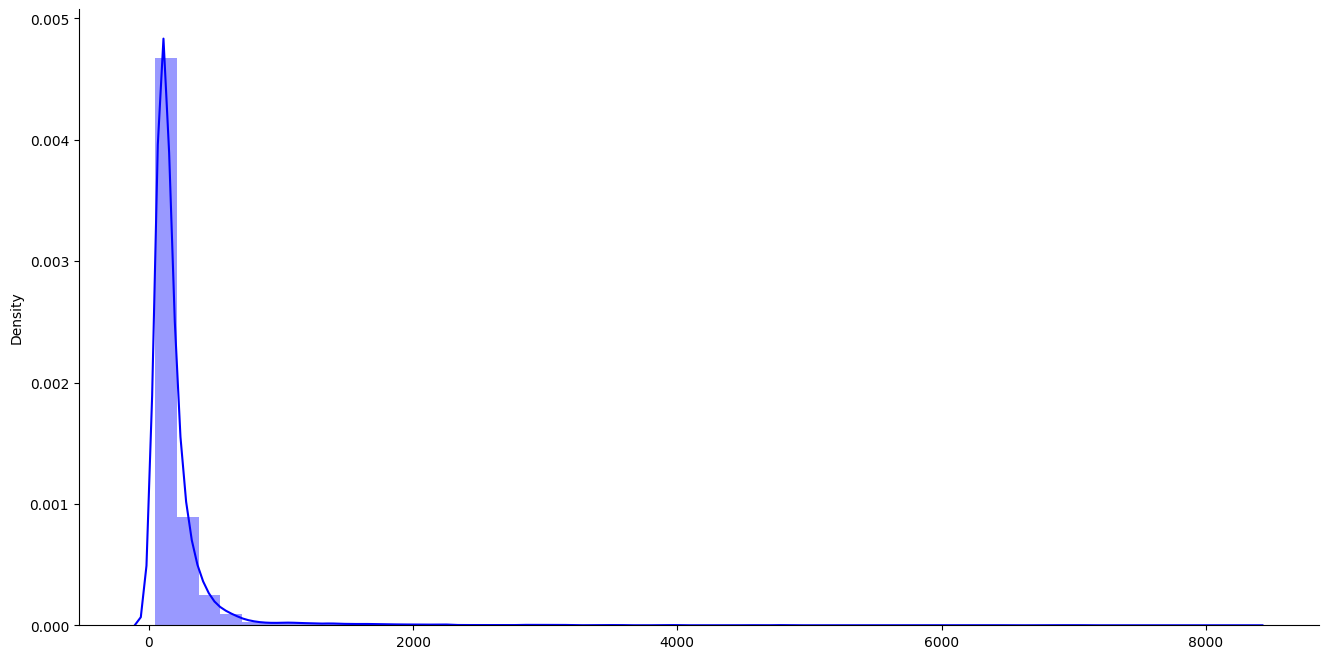

In [18]:
plt.figure(figsize=(16, 8))
sns.distplot(song_user.values, color='blue')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show();

In [19]:
print(f"A song is listened for an average of {np.mean(song_user)} users, with minimum {np.min(song_user)} and maximum {np.max(song_user)} users")

A song is listened for an average of 200.0 users, with minimum 48 and maximum 8277 users


So we already know that it is a very sparse matrix. Dealing with such a sparse matrix, we'll take a lot of memory and resources. To make our life easier, let's just select again all those users that have listened to at least 16 songs. Moreover, we are going to select only those songs which have been listened to by at least 200 users.

In [20]:
# Get how many songs each user have listened to
user_counts = df_songs.groupby('user_id')['song_id'].count()

# Filter users which have listen to at least 16 songs
user_ten_id = user_counts[user_counts > 16].index.to_list()

In [21]:
# Get how many user have listened to each song
song_counts = df_songs.groupby('song_id')['user_id'].count()

# Get songs which have been listened at least 4 times
song_ten_id = song_counts[song_counts > 200].index.to_list()

In [22]:
# Filtered the dataset to keep only those users with more than 16 listened
df_song_reduced = df_songs[(df_songs['user_id'].isin(user_ten_id)) & (df_songs['song_id'].isin(song_ten_id))].reset_index(drop=True)

In [23]:
df_song_reduced.shape

(950353, 7)

### Model and recommendations

Matrix Factorization is a powerful way to implement a recommendation system. The idea behind it is to represent users and items in a lower-dimensional latent space.

So, in other words, Matrix factorization methods decompose the original sparse user-item matrix into lower dimensionality less sparse rectangular matrices with latent features.

This does not only solve the sparsity issue but also makes the method scalable. It doesn't matter how big the matrix is, you can always find lower dimensionality matrices that are a true representation of the original one.

Among the different matrix factorization techniques, we found the popular singular value decomposition (SVD).

This can be an abstract concept as we deepen into the mathematical foundations. But we'll try to keep it as simple as possible.
Imagine we have a matrix A that contains the data for n users x m songs. This matrix can be decomposed uniquely into 3 matrices; let's called them U, S, and V.

In terms of our song recommender:

- U is an n users x r user-latent feature matrix
- V is an m songs x r song-latent feature matrix
- S is an r x r non-negative diagonal matrix containing the singular values of the original matrix.

Instead of working with the implicit rating as it is, we'll apply the binning technique.
  
We'll define 10 categories. The original data values which fall into the interval from 0 to 1, will be replaced by the representative rating of 1; if they fall into the interval 1 to 2, they will be replaced by 2; and so on and so forth. The last category will be assigned to original values ranging from 9 to 2213.

In [24]:
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 2214]

In [25]:
df_song_reduced['listen_count'] = pd.cut(df_song_reduced['listen_count'], bins=bins, labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [26]:
listen_counts = pd.DataFrame(df_song_reduced.groupby('listen_count').size(), columns=['count']).reset_index(drop=False)

/tmp/ipykernel_526/121297320.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  listen_counts = pd.DataFrame(df_song_reduced.groupby('listen_count').size(), columns=['count']).reset_index(drop=False)


/tmp/ipykernel_526/4201428587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='listen_count', y='count', palette='Set3', data=listen_counts)


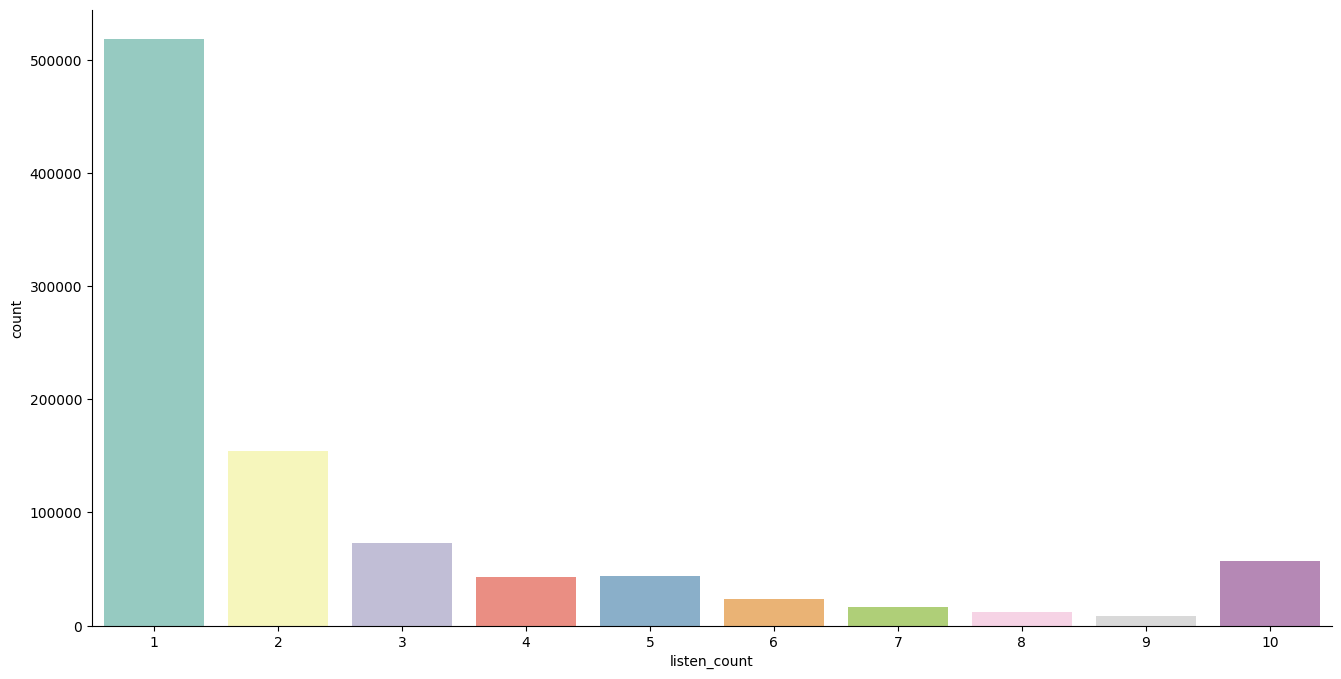

In [27]:
plt.figure(figsize=(16, 8))
sns.barplot(x='listen_count', y='count', palette='Set3', data=listen_counts)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show();

For this topic, we are going to use a fun package called `surprise`. Surprise is an easy-to-use Python library specially designed for recommender systems.

To load a dataset from our DataFrame, we will use the load_from_df() method.

We will need to pass the following parameters:  

   - df: The dataframe containing the ratings. It must have three columns, corresponding to the user ids, the song ids, and the ratings.
   - reader (Reader): A reader to read the file. Only the rating_scale field needs to be specified.

In [28]:
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(df_song_reduced[['user_id', 'song_id', 'listen_count']], reader)

And as always, we split the set into training and testing.

In [29]:
trainset, testset = train_test_split(data, test_size=.25)

We'll use the built-in function for SVD. First, a set of parameters is going to be defined to search for the best parameters for the model.

The `GridSearchCV` class will compute accuracy metrics for the SVDalgorithm on the combinations of parameters selected, over a cross-validation procedure. This is useful for finding the best set of parameters for a prediction algorithm.

In [30]:
param_grid = {'n_factors': [160],
              'n_epochs': [100],
              'lr_all': [0.001, 0.005],
              'reg_all': [0.08, 0.1]}

In [31]:
grid_search_svd = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, joblib_verbose=4, n_jobs=-2)

In [32]:
# find the best parameters for the model
grid_search_svd.fit(data)
find_algo = grid_search_svd.best_estimator['rmse']
print(grid_search_svd.best_score['rmse'])
print(grid_search_svd.best_params['rmse'])

2.199015720139496
{'n_factors': 160, 'n_epochs': 100, 'lr_all': 0.005, 'reg_all': 0.1}


[Parallel(n_jobs=-2)]: Done  12 out of  12 | elapsed: 11.8min finished


In [33]:
# Perform the cross validation
cross_validate(find_algo, data, measures=['RMSE'], cv=5, verbose=True)

Evaluating RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    2.1804  2.1837  2.1711  2.1762  2.1699  2.1763  0.0053  
Fit time          65.17   71.48   67.31   70.15   67.09   68.24   2.27    
Test time         2.14    2.77    2.00    3.06    2.17    2.43    0.41    


{'test_rmse': array([2.18044254, 2.18369869, 2.1710949 , 2.17622975, 2.16987017]),
 'fit_time': (65.17030143737793,
  71.47859716415405,
  67.31485724449158,
  70.14712738990784,
  67.08968877792358),
 'test_time': (2.141206741333008,
  2.7733089923858643,
  2.0000929832458496,
  3.0608677864074707,
  2.173535108566284)}

After finding the best parameters for the model, we create our final model, train it and find the error for the test set.

In [34]:
final_algorithm = SVD(n_factors=160, n_epochs=100, lr_all=0.005, reg_all=0.1)
final_algorithm.fit(trainset)
test_predictions = final_algorithm.test(testset)
print(f"The RMSE is {accuracy.rmse(test_predictions, verbose=True)}")

RMSE: 2.1886
The RMSE is 2.1885917950532985
